In [1]:
import torch

from tts.config.ndaligner.data_config import DataConfig
from tts.config.ndaligner.training_module_config import NDAlignerTrainingModuleConfigs
from tts.config.utils.io import load_config
from tts.models.ndaligner import init_nd_aligner_training_module

/home/blue2959/monotonic_tts/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

aligner_data_cfg_path = "./runs/nd_aligner_vctk_v1.4_ablation_20260628-105633/data_config.json"
aligner_training_module_cfg_path = "./runs/nd_aligner_vctk_v1.4_ablation_20260628-105633/model_config.json"
aligner_training_module_ckpt_path = "./runs/nd_aligner_vctk_v1.4_ablation_20260628-105633/checkpoints_timit_bae/best_step_timit_bae_0.022839_step_56500_epoch_12.pth"

TIMIT_ROOT = "/shared/data_zfs/blue2959/TIMIT/TEST"

In [3]:
data_config = load_config(aligner_data_cfg_path, DataConfig)
model_config = load_config(aligner_training_module_cfg_path, NDAlignerTrainingModuleConfigs,)

aligner_training_module = init_nd_aligner_training_module(
    config=model_config,
    device=device,
)
aligner_training_module.load_checkpoint(
    ckpt_path=aligner_training_module_ckpt_path,
    device=device,
)
aligner = aligner_training_module.nd_aligner.eval()

/home/blue2959/monotonic_tts/.venv/lib/python3.13/site-packages/speechbrain/utils/autocast.py:188: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  wrapped_fwd = torch.cuda.amp.custom_fwd(fwd, cast_inputs=cast_inputs)


SpeechBrain ECAPA-TDNN SpeakerEncoder loaded on cuda.
Loading nested state_dict from key 'model' in ./runs/nd_aligner_vctk_v1.4_ablation_20260628-105633/checkpoints_timit_bae/best_step_timit_bae_0.022839_step_56500_epoch_12.pth
⚠️ Checkpoint load summary (strict=False):
  - Unexpected top-level modules: ['vocoder']
Checkpoint loading process finished.


In [4]:
from tts.tokenizer.espeak_tokenizer import ESPEAKTokenizer
from tts.models.modules.spk_encoder import ECAPASpeakerEncoder

txt_tokenizer = ESPEAKTokenizer()
spk_encoder = ECAPASpeakerEncoder(device=device)

SpeechBrain ECAPA-TDNN SpeakerEncoder loaded on cuda.


In [5]:
wav_path = "/shared/data_zfs/blue2959/LJSpeech-1.1/wavs/LJ001-0020.wav"
text = "the lower-case being in fact invented in the early Middle Ages."

In [6]:
assert aligner.input_maker is not None

batch = aligner.input_maker.make_with_audio(
    wav_paths=wav_path,
    scripts=[text],
)

cond = (
    torch.tensor(
        0.0,
        device=batch.x.device,
    )
    if batch.cond is None
    else batch.cond
)

features = aligner.compute_alignments(
    x=batch.x,
    x_lengths=batch.x_lengths,
    y=batch.y,
    y_lengths=batch.y_lengths,
    cond=cond,
    compute_soft_path=True,
    compute_hard_path=True,
)

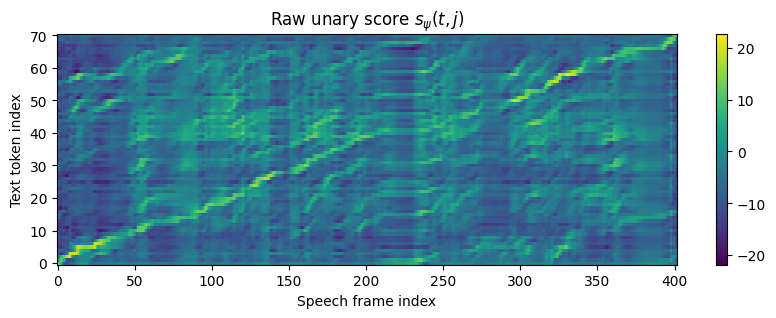

In [7]:
import matplotlib.pyplot as plt

raw_unary = features.raw_unary.squeeze(0).T.cpu().detach().numpy()

plt.figure(figsize=(10, 3))
plt.imshow(raw_unary, origin="lower", aspect="auto", interpolation="nearest")
plt.xlabel("Speech frame index")
plt.ylabel("Text token index")
plt.title(r"Raw unary score $s_\psi(t,j)$")
plt.colorbar()
plt.show()

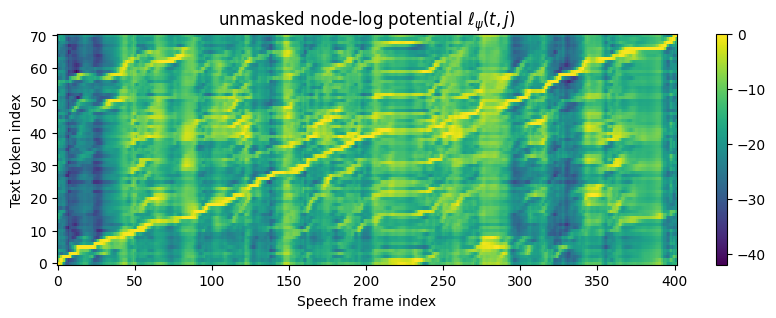

In [12]:
import matplotlib.pyplot as plt

raw_unary = features.log_b.squeeze(0).T.cpu().detach().numpy()

plt.figure(figsize=(10, 3))
plt.imshow(raw_unary, origin="lower", aspect="auto", interpolation="nearest")
plt.colorbar()
plt.xlabel("Speech frame index")
plt.ylabel("Text token index")
plt.title(r"unmasked node-log potential $\ell_\psi(t,j)$")
plt.show()

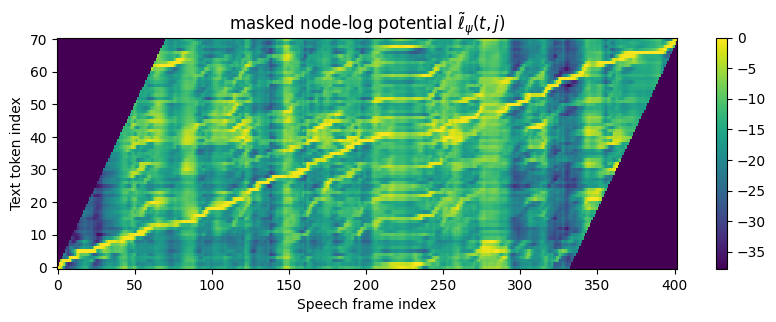

In [13]:
import torch
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Take one sample
# ------------------------------------------------------------
b = 0

log_b = features.log_b[b]  # (T_s, T_t)

s_len = int(batch.y_lengths[b].item())
t_len = int(batch.x_lengths[b].item())

log_b = log_b[:s_len, :t_len]  # (T_s, T_t)

# ------------------------------------------------------------
# 2. Strict monotone reachability mask
#    0-indexed version:
#        reachable from start: j <= t
#        completable to end:  (N - 1 - j) <= (T - 1 - t)
# ------------------------------------------------------------
device = log_b.device

t = torch.arange(s_len, device=device).view(s_len, 1)
j = torch.arange(t_len, device=device).view(1, t_len)

reachable = (j <= t) & ((t_len - 1 - j) <= (s_len - 1 - t))

# ------------------------------------------------------------
# 3. Mask log_b, but use finite minimum instead of -inf for plotting
# ------------------------------------------------------------
fill_value = log_b[reachable].min()
masked_log_b = log_b.masked_fill(~reachable, fill_value)

# ------------------------------------------------------------
# 4. Plot masked node-log potential \tilde{\ell}_psi(t,j)
# ------------------------------------------------------------
masked_log_b_np = masked_log_b.T.cpu().detach().numpy()

plt.figure(figsize=(10, 3))
plt.imshow(
    masked_log_b_np,
    origin="lower",
    aspect="auto",
    interpolation="nearest",
)
plt.colorbar()
plt.xlabel("Speech frame index")
plt.ylabel("Text token index")
plt.title(r"masked node-log potential $\tilde{\ell}_\psi(t,j)$")
plt.show()

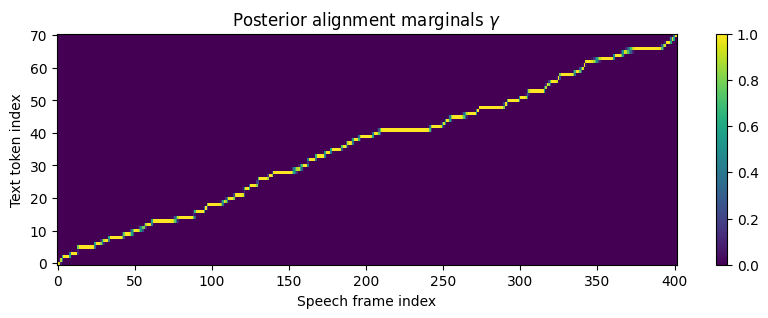

In [10]:
import matplotlib.pyplot as plt

soft_attn = features.soft_attn.squeeze(0).T.cpu().detach().numpy()

plt.figure(figsize=(10, 3))
plt.imshow(soft_attn, origin="lower", aspect="auto", interpolation="nearest")
plt.colorbar()
plt.xlabel("Speech frame index")
plt.ylabel("Text token index")
plt.title(r"Posterior alignment marginals $\gamma$")
plt.show()

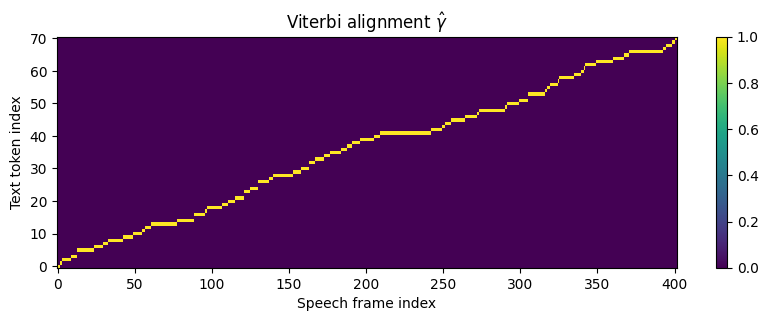

In [11]:
import matplotlib.pyplot as plt

hard_attn = features.hard_attn.squeeze(0).T.cpu().detach().numpy()

plt.figure(figsize=(10, 3))
plt.imshow(hard_attn, origin="lower", aspect="auto", interpolation="nearest")
plt.colorbar()
plt.xlabel("Speech frame index")
plt.ylabel("Text token index")
plt.title(r"Viterbi alignment $\hat{\gamma}$")
plt.show()